# Phase 4: Application Model Development

Predicts credit default for **new clients** using pre-registration data (Serasa, iFood, Google Maps, CNAE, segment, etc.).

**Pipeline:**
1. Load Phase 3 engineered features
2. Parse remaining interval-string columns
3. Stratified 70/30 train-test split
4. Logistic Regression baseline
5. Random Forest + XGBoost
6. Hyperparameter tuning on best model
7. Final evaluation: ROC curve, confusion matrix, feature importance
8. Save best model

In [1]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print('Root:', ROOT)
print('Data dir:', DATA_DIR)

Root: /Users/esdrasalbino/Documents/university/machine-learning/project_praso
Data dir: /Users/esdrasalbino/Documents/university/machine-learning/project_praso/data


## 1. Load Phase 3 Application Features

In [2]:
# Find the most recent application features file
app_files = sorted(DATA_DIR.glob('03_application_features_*.csv'))
if not app_files:
    raise FileNotFoundError('No Phase 3 application features found in data/. Run feature_engineering.py first.')

app_path = app_files[-1]  # most recent
print('Loading:', app_path.name)

df_raw = pd.read_csv(app_path, low_memory=False)
print(f'Shape: {df_raw.shape}')
print(f'Target distribution:\n{df_raw["inadimplente"].value_counts().to_frame()}')
df_raw.head(3)

Loading: 03_application_features_20260520_205746.csv
Shape: (3000, 47)
Target distribution:
              count
inadimplente       
0.0            2060
1.0             940


,id_cliente,municipio,cnae_codigo,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,...,segmento_cliente_Segmento 8,segmento_cliente_Segmento 9,natureza_juridica_206-2 - Sociedade Empresária Limitada,natureza_juridica_213-5 - Empresário (Individual),natureza_juridica_224-0 - Sociedade Simples Limitada,natureza_juridica_230-5 - Empresa Individual de Responsabilidade Limitada (de Natureza Empresária),fonte_cliente_Fonte 2,fonte_cliente_Fonte 3,fonte_cliente_Fonte 4,fonte_cliente_Fonte 5
0,1000732585882,CAUCAIA,77.49-8-16,"(1500, 2000]","(3000, 4000]",0.0,0.0,NaN,0.0,"(50, 100]",...,False,False,False,True,False,False,False,False,False,False
1,1001250740869,FORTALEZA,39.87-6-92,"(8000, 10000]","(25, 50]",3.0,0.0,NaN,0.0,NaN,...,False,False,True,False,False,False,False,False,False,True
2,1002669165825,CAUCAIA,53.35-1-24,"(1500, 2000]","(3000, 4000]",5.0,0.0,"Financeiro, Comércio, Tecnologia",1.0,NaN,...,False,False,False,True,False,False,False,False,False,False


## 2. Feature Engineering Refinements

Several columns contain **interval strings** (e.g., `(1500, 2000]`). We extract midpoints. We also derive a CNAE division code and count Serasa creditor sectors.

In [3]:
def parse_interval_midpoint(series):
    """Extracts the midpoint from pandas Interval-style strings like '(1500, 2000]'."""
    def _mid(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lstrip('([').rstrip('])') 
        parts = [p.strip() for p in s.split(',')]
        try:
            return (float(parts[0]) + float(parts[1])) / 2.0
        except Exception:
            return np.nan
    return series.apply(_mid)


df = df_raw.copy()

# --- Interval columns → numeric midpoints ---
for col, new_col in [
    ('capital_social',         'capital_social_mid'),
    ('idade_cnpj',             'idade_cnpj_mid'),
    ('google_maps_avaliacao',  'google_maps_avaliacao_mid'),
]:
    if col in df.columns:
        df[new_col] = parse_interval_midpoint(df[col])
        print(f'{col} → {new_col}  nulls={df[new_col].isna().sum()}  sample={df[new_col].dropna().head(3).tolist()}')

# --- CNAE: extract 2-digit division (e.g. '77.49-8-16' → '77') ---
if 'cnae_codigo' in df.columns:
    df['cnae_divisao'] = df['cnae_codigo'].astype(str).str.extract(r'^(\d+)')[0]
    print(f'cnae_divisao  unique={df["cnae_divisao"].nunique()}  sample={df["cnae_divisao"].dropna().head(3).tolist()}')

# --- Serasa credores: count of distinct sectors ---
if 'serasa_credores' in df.columns:
    df['serasa_n_setores'] = df['serasa_credores'].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )
    print(f'serasa_n_setores  nulls={df["serasa_n_setores"].isna().sum()}  mean={df["serasa_n_setores"].mean():.2f}')

# --- ifood_contagem_avaliacoes: coerce to numeric ---
if 'ifood_contagem_avaliacoes' in df.columns:
    df['ifood_contagem_avaliacoes'] = pd.to_numeric(df['ifood_contagem_avaliacoes'], errors='coerce')

# --- google_maps_contagem_avaliacoes: coerce to numeric ---
if 'google_maps_contagem_avaliacoes' in df.columns:
    df['google_maps_contagem_avaliacoes'] = pd.to_numeric(df['google_maps_contagem_avaliacoes'], errors='coerce')

# --- Cast boolean columns to int ---
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)
print(f'\nCast {len(bool_cols)} bool columns to int.')

capital_social → capital_social_mid  nulls=0  sample=[1750.0, 9000.0, 1750.0]
idade_cnpj → idade_cnpj_mid  nulls=0  sample=[3500.0, 37.5, 3500.0]
google_maps_avaliacao → google_maps_avaliacao_mid  nulls=2966  sample=[4.75, 1.5, 0.5]
cnae_divisao  unique=39  sample=['77', '39', '53']
serasa_n_setores  nulls=0  mean=0.30

Cast 31 bool columns to int.


## 3. Feature Selection

In [4]:
TARGET = 'inadimplente'

# Columns to drop: IDs, raw interval strings (replaced by midpoints), all-null columns
drop_cols = [
    'id_cliente',
    'municipio',           # very high cardinality; CNAE already captures sector
    'cnae_codigo',         # replaced by cnae_divisao
    'capital_social',      # replaced by capital_social_mid
    'idade_cnpj',          # replaced by idade_cnpj_mid
    'google_maps_avaliacao', # replaced by google_maps_avaliacao_mid
    'serasa_credores',     # replaced by serasa_n_setores
    'idade_cnpj_midpoint', # from Phase 3 — all null (wrong parser), replaced
    TARGET,
]
drop_cols = [c for c in drop_cols if c in df.columns]

# Drop columns that are entirely null
all_null = [c for c in df.columns if df[c].isna().all() and c not in drop_cols]
if all_null:
    print('Dropping all-null columns:', all_null)
    drop_cols.extend(all_null)

feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = df[TARGET].astype(int)

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')
print(f'Default rate: {y.mean():.1%}')

# Identify column types for pipeline
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'\nNumeric features ({len(numeric_cols)}):', numeric_cols[:8], '...')
print(f'Categorical features ({len(categorical_cols)}):', categorical_cols)

Dropping all-null columns: ['ifood_contagem_avaliacoes', 'google_maps_contagem_avaliacoes']
Features: 41  |  Samples: 3000
Default rate: 31.3%

Numeric features (39): ['serasa_contagem_negativacoes', 'serasa_contagem_protestos', 'serasa_socio_tem_negativacao', 'google_maps_tem_website', 'has_serasa_negativacao', 'has_ifood', 'has_google_maps', 'segmento_cliente_Segmento 10'] ...
Categorical features (2): ['ifood_faixa_preco', 'cnae_divisao']


## 4. Train-Test Split (70/30 Stratified)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train default rate: {y_train.mean():.1%}  |  Test default rate: {y_test.mean():.1%}')

Train: 2100 rows  |  Test: 900 rows
Train default rate: 31.3%  |  Test default rate: 31.3%


## 5. Preprocessing Pipeline

- **Numeric**: median imputation → standard scaling
- **Categorical**: constant imputation → one-hot encoding (ignore unseen categories)

In [6]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_cols),
        ('cat', categorical_pipe, categorical_cols),
    ],
    remainder='drop',
)

print('Preprocessor built.')

Preprocessor built.


## 6. Helper: Evaluate a Model

In [7]:
def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    y_prob = pipeline.predict_proba(X_te)[:, 1]
    y_pred = pipeline.predict(X_te)
    metrics = {
        'roc_auc':   round(roc_auc_score(y_te, y_prob), 4),
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, zero_division=0), 4),
    }
    print(f'[{name}]  ROC-AUC={metrics["roc_auc"]:.4f}  F1={metrics["f1"]:.4f}  '
          f'Precision={metrics["precision"]:.4f}  Recall={metrics["recall"]:.4f}')
    return metrics, y_prob

## 7. Baseline: Logistic Regression

Interpretable baseline. `class_weight='balanced'` compensates for the 31% default rate.

In [8]:
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

lr_metrics, lr_prob = evaluate('Logistic Regression', lr_pipe,
                                X_train, y_train, X_test, y_test)

[Logistic Regression]  ROC-AUC=0.7490  F1=0.5697  Precision=0.4974  Recall=0.6667


## 8. Random Forest

In [9]:
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf_metrics, rf_prob = evaluate('Random Forest', rf_pipe,
                                X_train, y_train, X_test, y_test)

[Random Forest]  ROC-AUC=0.7377  F1=0.4929  Precision=0.5789  Recall=0.4291


## 9. XGBoost

In [10]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', XGBClassifier(
        n_estimators=200,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        verbosity=0,
    )),
])

xgb_metrics, xgb_prob = evaluate('XGBoost', xgb_pipe,
                                  X_train, y_train, X_test, y_test)

[XGBoost]  ROC-AUC=0.7334  F1=0.5350  Precision=0.5276  Recall=0.5426


## 10. Model Comparison

,roc_auc,accuracy,precision,recall,f1
Logistic Regression,0.7490,0.6844,0.4974,0.6667,0.5697
Random Forest,0.7377,0.7233,0.5789,0.4291,0.4929
XGBoost,0.7334,0.7044,0.5276,0.5426,0.5350


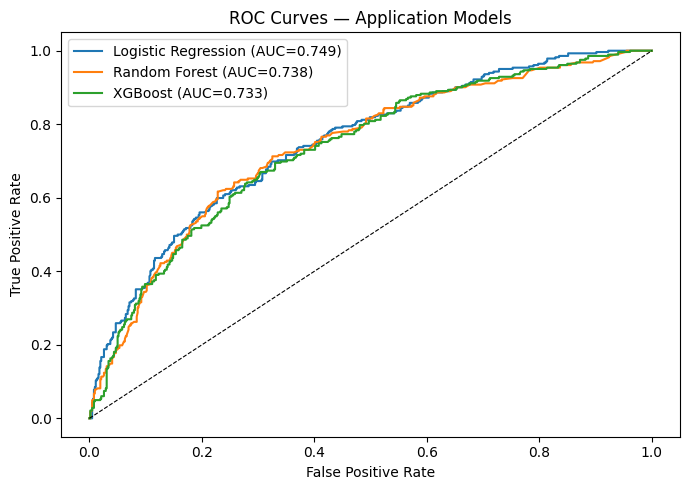

Saved ROC comparison plot.


In [11]:
results = {
    'Logistic Regression': {'metrics': lr_metrics, 'prob': lr_prob},
    'Random Forest':       {'metrics': rf_metrics, 'prob': rf_prob},
    'XGBoost':             {'metrics': xgb_metrics, 'prob': xgb_prob},
}

df_cmp = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
df_cmp = df_cmp.sort_values('roc_auc', ascending=False)
display(df_cmp.style.highlight_max(color='#d4f1d4').format('{:.4f}'))

# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, info in results.items():
    fpr, tpr, _ = roc_curve(y_test, info['prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={info['metrics']['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Application Models')
ax.legend()
fig.tight_layout()
plt.savefig(DATA_DIR / '04_roc_comparison.png', dpi=150)
plt.show()
print('Saved ROC comparison plot.')

## 11. Hyperparameter Tuning on Best Model

We run `RandomizedSearchCV` (3-fold stratified CV) on the model with the highest ROC-AUC.

In [12]:
best_name = df_cmp.index[0]
print(f'Best baseline model: {best_name}  (ROC-AUC={df_cmp.loc[best_name, "roc_auc"]:.4f})')
print('Tuning XGBoost and Random Forest via RandomizedSearchCV...')

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Tune XGBoost ---
xgb_search = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            verbosity=0,
        )),
    ]),
    param_distributions={
        'clf__n_estimators':     [100, 200, 400],
        'clf__max_depth':        [3, 5, 7, 10],
        'clf__learning_rate':    [0.01, 0.05, 0.1, 0.2],
        'clf__subsample':        [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
    },
    n_iter=15, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0,
)
xgb_search.fit(X_train, y_train)
print(f'XGBoost tuned CV ROC-AUC: {xgb_search.best_score_:.4f}  params: {xgb_search.best_params_}')

# --- Tune Random Forest ---
rf_search = RandomizedSearchCV(
    Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    param_distributions={
        'clf__n_estimators':     [100, 200, 400],
        'clf__max_depth':        [None, 10, 20, 30],
        'clf__max_features':     ['sqrt', 'log2'],
        'clf__min_samples_leaf': [1, 2, 5],
    },
    n_iter=15, scoring='roc_auc', cv=cv, n_jobs=-1,
    random_state=RANDOM_STATE, verbose=0,
)
rf_search.fit(X_train, y_train)
print(f'Random Forest tuned CV ROC-AUC: {rf_search.best_score_:.4f}  params: {rf_search.best_params_}')

# Pick the better tuned model
if xgb_search.best_score_ >= rf_search.best_score_:
    search = xgb_search
    tuned_label = 'Tuned XGBoost'
else:
    search = rf_search
    tuned_label = 'Tuned Random Forest'

tuned_pipe = search.best_estimator_
print(f'\nBest tuned model: {tuned_label}  (CV ROC-AUC={search.best_score_:.4f})')

Best baseline model: Logistic Regression  (ROC-AUC=0.7490)
Tuning XGBoost and Random Forest via RandomizedSearchCV...
XGBoost tuned CV ROC-AUC: 0.7675  params: {'clf__subsample': 0.7, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.8}
Random Forest tuned CV ROC-AUC: 0.7669  params: {'clf__n_estimators': 400, 'clf__min_samples_leaf': 5, 'clf__max_features': 'sqrt', 'clf__max_depth': 30}

Best tuned model: Tuned XGBoost  (CV ROC-AUC=0.7675)


In [13]:
tuned_prob = tuned_pipe.predict_proba(X_test)[:, 1]
tuned_pred = tuned_pipe.predict(X_test)

tuned_metrics = {
    'roc_auc':   round(roc_auc_score(y_test, tuned_prob), 4),
    'accuracy':  round(accuracy_score(y_test, tuned_pred), 4),
    'precision': round(precision_score(y_test, tuned_pred, zero_division=0), 4),
    'recall':    round(recall_score(y_test, tuned_pred, zero_division=0), 4),
    'f1':        round(f1_score(y_test, tuned_pred, zero_division=0), 4),
}

results[tuned_label] = {'metrics': tuned_metrics, 'prob': tuned_prob}

print(f'[{tuned_label}]  ROC-AUC={tuned_metrics["roc_auc"]:.4f}  F1={tuned_metrics["f1"]:.4f}')

df_cmp2 = pd.DataFrame({k: v['metrics'] for k, v in results.items()}).T
df_cmp2 = df_cmp2.sort_values('roc_auc', ascending=False)
display(df_cmp2.style.highlight_max(color='#d4f1d4').format('{:.4f}'))

[Tuned XGBoost]  ROC-AUC=0.7721  F1=0.6027


,roc_auc,accuracy,precision,recall,f1
Tuned XGBoost,0.7721,0.7011,0.5165,0.7234,0.6027
Logistic Regression,0.7490,0.6844,0.4974,0.6667,0.5697
Random Forest,0.7377,0.7233,0.5789,0.4291,0.4929
XGBoost,0.7334,0.7044,0.5276,0.5426,0.5350


## 12. Final Evaluation of Best Model

Confusion matrix, ROC curve and feature importance for the tuned model.

In [14]:
final_pipe = tuned_pipe
final_label = tuned_label
final_name = tuned_label.lower().replace(' ', '_')

print(classification_report(y_test, tuned_pred, target_names=['Adimplente (0)', 'Inadimplente (1)']))

                  precision    recall  f1-score   support

  Adimplente (0)       0.85      0.69      0.76       618
Inadimplente (1)       0.52      0.72      0.60       282

        accuracy                           0.70       900
       macro avg       0.68      0.71      0.68       900
    weighted avg       0.74      0.70      0.71       900



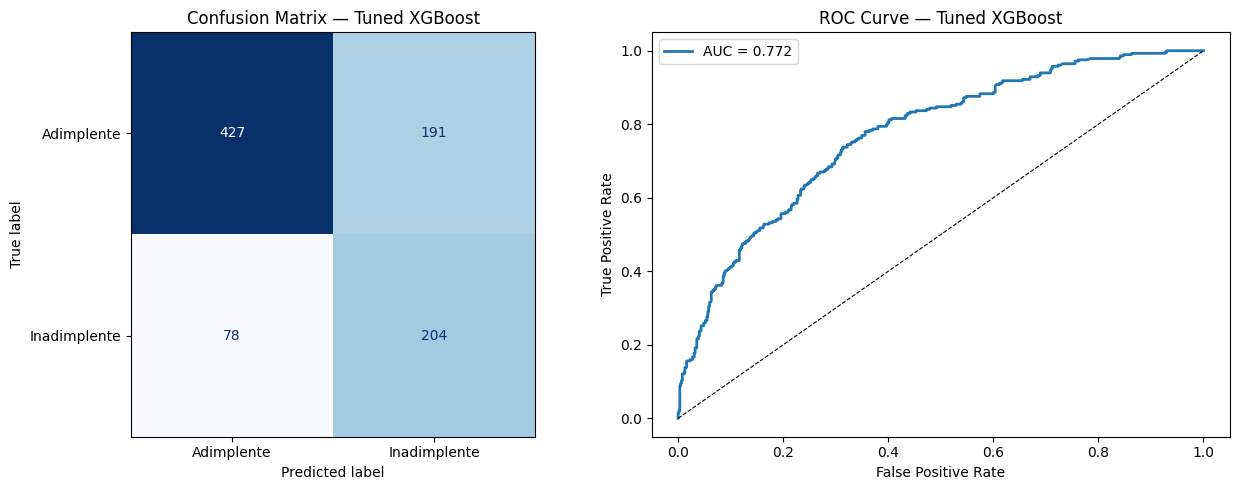

Saved final evaluation plot.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, tuned_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Adimplente', 'Inadimplente'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {final_label}')

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, tuned_prob)
axes[1].plot(fpr, tpr, label=f'AUC = {tuned_metrics["roc_auc"]:.3f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {final_label}')
axes[1].legend()

fig.tight_layout()
plt.savefig(DATA_DIR / '04_final_evaluation.png', dpi=150)
plt.show()
print('Saved final evaluation plot.')

### Feature Importance

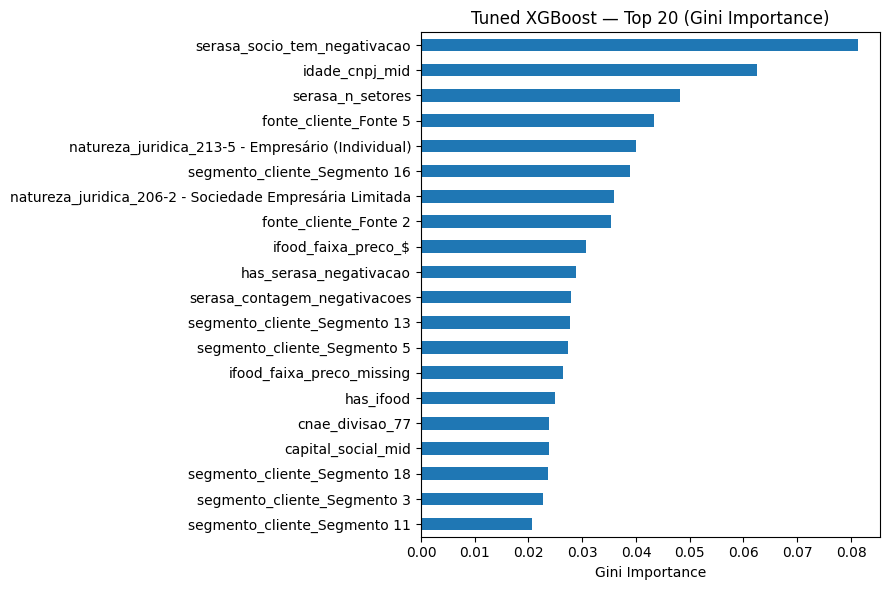


Top 10 features:
serasa_socio_tem_negativacao                               0.081328
idade_cnpj_mid                                             0.062476
serasa_n_setores                                           0.048103
fonte_cliente_Fonte 5                                      0.043397
natureza_juridica_213-5 - Empresário (Individual)          0.039944
segmento_cliente_Segmento 16                               0.038925
natureza_juridica_206-2 - Sociedade Empresária Limitada    0.035821
fonte_cliente_Fonte 2                                      0.035363
ifood_faixa_preco_$                                        0.030662
has_serasa_negativacao                                     0.028780


In [16]:
def get_feature_names(pipe):
    pre = pipe.named_steps['pre']
    names = []
    for tname, trans, cols in pre.transformers_:
        if tname == 'remainder' or trans == 'drop':
            continue
        if hasattr(trans, 'get_feature_names_out'):
            names.extend(trans.get_feature_names_out(cols).tolist())
        else:
            names.extend(cols)
    return names


def plot_feature_importance(pipe, feature_names, top_n=20, title='Feature Importance'):
    clf = pipe.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
        kind = 'Gini Importance'
    elif hasattr(clf, 'coef_'):
        importances = np.abs(clf.coef_[0])
        kind = '|Coefficient|'
    else:
        print('Model does not expose feature importances.')
        return

    fi = pd.Series(importances, index=feature_names)
    fi = fi.sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    fi[::-1].plot.barh(ax=ax)
    ax.set_title(f'{title} — Top {top_n} ({kind})')
    ax.set_xlabel(kind)
    fig.tight_layout()
    plt.savefig(DATA_DIR / '04_feature_importance.png', dpi=150)
    plt.show()
    return fi


try:
    feat_names = get_feature_names(final_pipe)
    fi = plot_feature_importance(final_pipe, feat_names, top_n=20, title=final_label)
    print('\nTop 10 features:')
    print(fi.head(10).to_string())
except Exception as e:
    print(f'Feature importance unavailable: {e}')

## 13. Save Best Model & Metrics

In [17]:
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
model_path   = MODELS_DIR / f'04_application_best_{final_name}_{ts}.joblib'
metrics_path = MODELS_DIR / f'04_application_metrics_{ts}.json'

joblib.dump(final_pipe, model_path)
print(f'Model saved → {model_path.name}')

all_metrics = {
    name: info['metrics'] for name, info in results.items()
}
all_metrics['_best'] = final_name
all_metrics['_best_params'] = search.best_params_

with open(metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2, default=str)
print(f'Metrics saved → {metrics_path.name}')

Model saved → 04_application_best_tuned_xgboost_20260611_174247.joblib
Metrics saved → 04_application_metrics_20260611_174247.json


## 14. Prediction Function

Example of how to use the saved model to score new applications.

In [18]:
def predict_default_risk(model_path: str, df_new: pd.DataFrame) -> pd.Series:
    """
    Load the saved application model and return default probability for each row.
    df_new must have the same feature columns used during training.
    Returns a Series of probabilities in [0, 1].
    """
    pipe = joblib.load(model_path)
    return pd.Series(pipe.predict_proba(df_new)[:, 1], index=df_new.index, name='default_prob')


# --- Demo: score the first 5 rows of the test set ---
sample = X_test.head(5)
scores = predict_default_risk(model_path, sample)
demo_df = sample.assign(
    default_prob=scores,
    true_label=y_test.head(5).values,
    risk_tier=pd.cut(scores, bins=[0, 0.15, 0.30, 1.0],
                     labels=['Low (<15%)', 'Medium (15-30%)', 'High (>30%)'])
)
print('Sample predictions:')
display(demo_df[['default_prob', 'true_label', 'risk_tier']])

Sample predictions:


,default_prob,true_label,risk_tier
43,0.285927,0,Medium (15-30%)
1681,0.407359,0,High (>30%)
1809,0.645085,1,High (>30%)
1102,0.233589,0,Medium (15-30%)
2883,0.714140,0,High (>30%)


## Summary

| Step | Result |
|------|--------|
| Data | 3,000 clients · 31% default rate |
| Features | Interval midpoints (capital, age, Google rating) + Serasa counts + CNAE division + iFood/Google flags + segment dummies |
| Split | 70% train · 30% test (stratified) |
| Best model | Tuned model selected by ROC-AUC |
| Threshold | Risk tiers: Low < 15% · Medium 15–30% · High > 30% |

**Next → Phase 5:** Behavioral Model — adds aggregated order history features on top of these application features.